{{<video https://youtu.be/4zdvQMcWths?si=MB4uWtC_7-xMBiC2>}}

<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/Quiz6.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

In [1]:
import torch
import matplotlib.pyplot as plt 

# 1. 경사하강법 

아래의 함수를 고려하자. 

$$f(x)=x^2+ \frac{x^2}{x^2+1}$$

이 함수를 최소화하는 값 $x_{sol}$을 구하고자 한다. 

함수의 개형을 그려보고 경사하강법을 진행할 수 있는지 판단하라. 경사하강법을 진행할 수 있다면 `x_sol=0.5` 에서 경사하강법을 2회 진행하고 아래의 표를 완성하라. (이때 $\alpha=0.1$ 로 설정하고 $f'(x_{sol})$은 적당한 정확도로 근사계산 할 것)

| 횟수 | $x_{sol}$ (update 전) | $f'(x_{sol})$ | $x_{sol}$ (update 후) | 
|:--:|:--:|:--:|:--:|
| 1 | 0.5 | ?? | ?? | 
| 2 | ?? | ?? | ?? | 


> 답안제출양식: 그래프개형 그린 뒤 경사하강법 사용가능여부를 판단하고 경사하강법이 가능하다면 위의 표를 채워서 제출 // 코드는 제시할 필요 없음

::: {.callout-note collapse="true"}
## 정답 보기

In [2]:
def f(x):
    return x**2 + x**2/(x**2+1)
x = torch.linspace(-5,5,1000)
# plt.plot(x,f(x)) # -- 경사하강법적용가능

In [3]:
x_sol = 0.5 
alpha = 0.1 

In [4]:
print(x_sol) # 업데이트전
slope = (f(x_sol+0.0001)-f(x_sol))/0.0001
print(slope) # 기울기 
x_sol = x_sol - alpha * slope 
print(x_sol) # 업데이트후 

0.5
1.640112793856452
0.3359887206143548


In [5]:
print(x_sol) # 업데이트전
slope = (f(x_sol+0.0001)-f(x_sol))/0.0001
print(slope) # 기울기 
x_sol = x_sol - alpha * slope 
print(x_sol) # 업데이트후

0.3359887206143548
1.214690004170682
0.2145197201972866


:::

# 2. 회귀분석 

아래의 자료를 관측하였다고 하자. 

In [6]:
x = torch.tensor([
    -1.1585, -1.0528, -0.8023, -0.7788, -0.7018, -0.6923,
    -0.6371, -0.6173, -0.4399, -0.4356, -0.4143, -0.3761,
    -0.3639, -0.3006, -0.2797, -0.2123, -0.1962, -0.1117,
    -0.1084, -0.0215,  0.1594,  0.1654,  0.3392,  0.4504,
     0.4978,  0.7436,  0.8244,  0.8587,  0.9635,  1.0614
])

In [7]:
y = torch.tensor([
    -6.5200, -5.8359, -5.3639, -5.1654, -4.5664, -4.3141,
    -4.6552, -3.7561, -4.5129, -4.4500, -4.4445, -3.6102,
    -3.6236, -3.0639, -3.2406, -3.7088, -2.9196, -1.9855,
    -2.8198, -2.7340, -2.6920, -2.2963, -1.7646, -0.6208,
    -1.7411,  0.4475,  0.3451, -0.1648, -0.1344,  0.9861
])

강의노트에서 나온 방법을 활용하여 $(x_i,y_i)$를 적당히 잘 관통하는 추세선을 찾아라.

> 답안제출양식: $y_i = ?? + ?? x_i$ 에서 ?? 자리만 채워서 제출. // 그래프개형, 경사하강법 사용가능여부 판단 여부 작성하여 제출할 필요없음. 코드작성하여 제출할 필요 없음. 

::: {.callout-note collapse="true"}
## 정답 보기

In [8]:
b0=0
b1=0
alpha= 0.001
def l(b0,b1):
    return torch.sum((y-(b0+b1*x))**2)
for dummy in range(1000):
    b0_grad = (l(b0+0.0001,b1) - l(b0,b1))/0.0001
    b1_grad = (l(b0,b1+0.0001) - l(b0,b1))/0.0001
    b0 = b0 - alpha * b0_grad
    b1 = b1 - alpha * b1_grad
print(b0,b1)

tensor(-2.5841) tensor(3.1360)


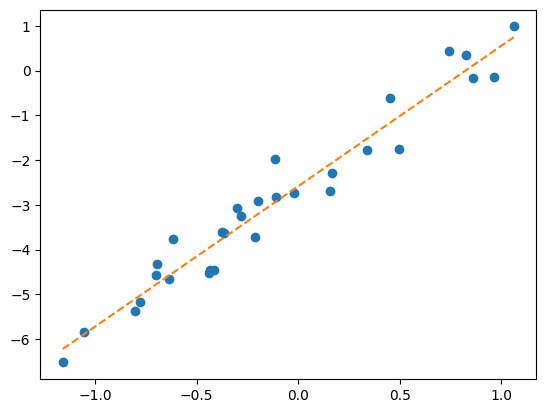

In [9]:
plt.plot(x,y,'o')
plt.plot(x,-2.5841 + 3.1360*x,'--')

:::

# 3. 경사하강법 & 회귀분석 이해도 점검 (이지선다)

> 답안제출양식: 답만써서 내면 됩니다. 

**[문제 1]** 1차원 경사하강법의 업데이트 수식 $x_{sol} \leftarrow x_{sol} - \alpha \times f'(x_{sol})$에서 $f'(x_{sol})$의 부호가 양수일 때, $x_{sol}$은 어느 방향으로 이동하는가?

① 오른쪽(증가 방향)

② 왼쪽(감소 방향)

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 2]** 경사하강법에서 점이 최솟값에 가까워질수록 기울기의 절대값은?

① 커진다

② 작아진다

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 3]** 학습률 $\alpha$의 값에 따른 현상으로 올바르지 않은 것은? -- 문제오류 

① alpha가 작을수록 천천히 최소값으로 수렴한다

② alpha가 커지면 항상 발산한다

**[문제 4]** $f(x) = \frac{1}{4}(x-2)^2$의 최솟값을 찾기 위해 $x_{sol} = 2.24$에서 시작했을 때, $f(x_{sol}), f(x_{sol}+0.1), f(x_{sol}-0.1)$을 비교하였다. 다음 업데이트에서 $x_{sol} - 0.1$ (왼쪽으로 이동)해야 하는 이유는?

① 최솟값이 2이기 때문에

② 세 값 중 $f(x_{sol}-0.1)$이 가장 작기 때문에

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 5]** 아래의 코드에 대한 비판으로 `slope = (1/2)*(x_sol-2)`를 직접 치는 것이 불가능할 수도 있다고 언급하였다. 그 이유는?

```python
alpha = 1.00
x_sol = 2.23
for dummy in range(30):
    slope = (1/2)*(x_sol-2) # f'(x) = 1/2*(x-2)
    x_sol = x_sol - alpha*slope
```

① $f'(x)$의 공식을 모를 수도 있기 때문

② 컴퓨터가 분수 계산을 못하기 때문

::: {.callout-note collapse="true"}
## 정답 보기

**답: ①**

:::

**[문제 6]** 미분 공식을 모를 때 미분계수 $f'(x_{sol})$을 근사하는 방법은?

① $\frac{f(x_{sol}+h)-f(x_{sol})}{h}$를 이용

② $f(x_{sol}+h) - f(x_{sol})$를 이용

::: {.callout-note collapse="true"}
## 정답 보기

**답: ①**

:::

**[문제 7]** 2차원 경사하강법에서 그래디언트 $\nabla f(x_{sol}, y_{sol})$는 무엇을 의미하는가?

① $\lim_{h\to 0}\frac{f(x_{sol}+h, y_{sol})-f(x_{sol}, y_{sol})}{h}$를 첫 번째 원소로, $\lim_{h\to 0}\frac{f(x_{sol}, y_{sol}+h)-f(x_{sol}, y_{sol})}{h}$를 두 번째 원소로 하는 벡터

② 함수 $f$가 최댓값을 갖는 점의 좌표를 나타내는 벡터

::: {.callout-note collapse="true"}
## 정답 보기

**답: ①**

:::

**[문제 8]** 아래의 알고리즘에 대한 설명으로 올바른 것은?

```python
for dummy in range(5):
    x_grad = (f(x_sol+0.01, y_sol) - f(x_sol,y_sol))/0.01
    x_sol = x_sol - alpha * x_grad
    y_grad = (f(x_sol, y_sol+0.01) - f(x_sol,y_sol))/0.01
    y_sol = y_sol - alpha * y_grad
```

① $x$와 $y$를 동시에 업데이트하므로 경사하강법이다

② $x$를 먼저 업데이트한 후 변경된 $x$ 값을 이용하여 $y$를 업데이트하므로 경사하강법이 아니다

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 9]** 강의노트에서 2차원 최적화를 위한 두 알고리즘을 비교했다. 알고리즘1은 $(x_{sol}, y_{sol})$ 주변 9개 점을 모두 조사하고, 알고리즘2는 $x$와 $y$ 축 방향으로만 조사한다. 알고리즘2가 더 실용적인 이유는?

① 알고리즘2가 정확도가 더 높기 때문

② 알고리즘1은 차원이 높아질수록 조사해야 할 점의 개수가 기하급수적으로 증가하기 때문

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 10]** 강의노트 `# 3. 경사하강법 > ## B. 2차원 > 고차원일 경우?`에 제시된 아래 표를 참고하라.

|차원 $d$| 알고리즘1 | 알고리즘2 |
|:--:|:--:|:--:|
|2 | 9 | 5|
|3 | 27 | 7 |
|...| ... | ... |
| 10 | 59049 | 21|

차원 $d=5$일 때, 알고리즘1과 알고리즘2의 계산량은?

① 알고리즘1: 11개, 알고리즘2: 243개

② 알고리즘1: 243개, 알고리즘2: 11개

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 16]** 회귀분석에서 손실함수(loss function)로 사용되는 SSE의 수식은?

① $\sum_{i=1}^{n}|y_i - (\beta_0 + \beta_1 x_i)|$

② $\sum_{i=1}^{n}(y_i - (\beta_0 + \beta_1 x_i))^2$

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 12]** 아이스아메리카노 예제에서 박혜원씨가 생각하는 "본질을 꿰뚫어 본다"는 것의 의미는?

① 모든 관측치를 정확히 통과하는 곡선을 찾는다

② $(x_i, y_i)$를 적당히 잘 관통하는 추세선을 찾는다

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 17]** 회귀분석에서 loss가 작다는 것은 무엇을 의미하는가?

① 대체로 $y_i \approx \beta_0 + \beta_1 x_i$가 성립한다

② 대체로 $y_i$와 $\beta_0 + \beta_1 x_i$의 차이가 크다

::: {.callout-note collapse="true"}
## 정답 보기

**답: ①**

:::

**[문제 18]** 회귀분석의 목표는 무엇인가?

① 손실함수를 최대화하는 $\beta_0, \beta_1$을 찾는다

② 손실함수를 최소화하는 $\beta_0, \beta_1$을 찾는다

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 11]** 강의노트에서 박혜원씨가 "이 세상이 시뮬레이션 아니야?"라고 의심한 이유는?

① 관측한 데이터가 $\text{sales}_i = \beta_0 + \beta_1 \text{temp}_{i} + \epsilon_i$ 모형에서 나온 것 같다는 느낌 때문

② 모든 점이 정확히 직선 위에 있기 때문

::: {.callout-note collapse="true"}
## 정답 보기

**답: ①**

:::

**[문제 15]** 강의노트에서 박혜원씨는 시도2 $[\beta_0, \beta_1] = [2.5, 3.5]$와 시도3 $[\beta_0, \beta_1] = [2.3, 3.5]$ 중 어느 것이 더 좋은지 판단하기 어려웠다. 이를 해결하기 위해 도입한 것은?

① 더 많은 데이터를 수집한다

② loss의 개념을 도입하여 "적당함"을 수식화한다

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 14]** 강의노트에서 박혜원씨가 "본질을 꿰뚫어 본다"는 것은 수식으로 어떻게 표현되는가?

① 최대한 $y_i = \beta_0 + \beta_1 x_i$를 만족하도록 $\beta_0, \beta_1$을 선택하는 것

② 최대한 $y_i \approx \beta_0 + \beta_1 x_i$를 만족하도록 $\beta_0, \beta_1$을 선택하는 것

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 13]** 박혜원씨가 생각하기에, 관측한 데이터에서 점들이 정확한 직선으로 보이지 않는 이유는?

① 측정 도구가 잘못되었기 때문

② 각 관측치에 장난질($\epsilon_i$)이 섞여서 본질을 흐리고 있기 때문

::: {.callout-note collapse="true"}
## 정답 보기

**답: ②**

:::

**[문제 19]** 회귀분석에서 손실함수 $loss = \sum_{i=1}^{n}(y_i - (\beta_0 + \beta_1 x_i))^2$는 $\beta_0, \beta_1$의 함수로 볼 수 있다. 이것이 의미하는 것은?

① $\beta_0, \beta_1$ 값을 입력으로 주면 하나의 loss 값이 출력된다

② $x_i, y_i$ 값을 입력으로 주면 하나의 loss 값이 출력된다

::: {.callout-note collapse="true"}
## 정답 보기

**답: ①**

:::

**[문제 20]** 회귀분석에서 최적의 $\beta_0, \beta_1$을 찾는 문제를 경사하강법으로 풀 수 있는 이유는?

① 회귀분석 문제를 아래로 볼록한 손실함수 $l(\beta_0, \beta_1)$을 최소화하는 최적화 문제로 바꿀 수 있기 때문

② 회귀분석은 항상 $\beta_0 = 0, \beta_1 = 1$이 답이기 때문

::: {.callout-note collapse="true"}
## 정답 보기

**답: ①**

:::